# EDA v2 — Dataset 2: Pakistan Healthcare

**Versión resumida y enfocada.** Aprovecha los hallazgos del EDA v1 para ir directo a lo que importa:
- Confirmación de naturaleza sintética
- La única brecha real: pública vs privada (costos)
- Recursos vs outcomes (spoiler: no correlacionan)
- Correlaciones económicas
- Feature engineering para fases siguientes

**Dataset:** 5,500 hospitales · 37 variables · Pakistán 2022–2024

In [ ]:
# === OPCION 1: Carga LOCAL (usar esta si corres en tu PC) ===
ruta_csv = '2_pakistan_healthcare_dataset.csv'

# === OPCION 2: Montar Google Drive ===
# from google.colab import drive
# drive.mount('/content/drive')
# ruta_csv = '/content/drive/MyDrive/RUTA_A_TU_ARCHIVO/2_pakistan_healthcare_dataset.csv'

# === OPCION 3: Subir archivo manualmente en Colab ===
# from google.colab import files
# uploaded = files.upload()
# ruta_csv = '2_pakistan_healthcare_dataset.csv'

In [ ]:
# Instalar librerias necesarias (descomentar si no las tenes instaladas)
# !pip install pandas numpy matplotlib seaborn plotly scipy scikit-learn
# pip install pandas numpy matplotlib seaborn plotly scipy scikit-learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

df = pd.read_csv('2_pakistan_healthcare_dataset.csv')
print(f'Shape: {df.shape}')
print(f'Nulos: {df.isnull().sum().sum()} | Duplicados: {df.duplicated().sum()}')
df.head(3)

Shape: (5500, 37)
Nulos: 0 | Duplicados: 0


,Hospital_ID,Hospital_Name,Sector,City,Province,Hospital_Type,Year,Total_Beds,ICU_Beds,Operation_Theatres,...,Insurance_Accepted,Patient_Satisfaction_Score,Mortality_Rate,Infection_Rate,Readmission_Rate,Waiting_Time_Minutes,Distance_from_City_Center,Ambulance_Available,Telemedicine_Service,Rural_Patients_Percentage
0,H10000,Hospital_TSDGA,Public,Sialkot,Punjab,Specialized,2024,1432,49,6,...,Yes,5.1,2.24,3.34,8.49,31,8.2,Yes,No,49
1,H10001,Hospital_VAXQQ,Private,Quetta,Balochistan,General,2023,905,29,4,...,Yes,7.3,0.66,6.70,7.76,5,29.1,No,Yes,15
2,H10002,Hospital_XABQD,Public,Kasur,Punjab,Specialized,2024,456,141,20,...,No,7.9,4.71,4.07,7.39,179,3.7,Yes,No,68


## 1. Calidad de datos y naturaleza sintética

El EDA v1 detectó señales de datos sintéticos. Acá los confirmamos con evidencia estadística.

In [2]:
# --- Estadísticas descriptivas compactas ---
num_cols = ['Mortality_Rate', 'Patient_Satisfaction_Score', 'Average_Treatment_Cost',
            'Infection_Rate', 'Readmission_Rate', 'Waiting_Time_Minutes',
            'Total_Beds', 'Total_Doctors', 'Government_Funding']

desc = df[num_cols].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
desc['cv'] = (desc['std'] / desc['mean']).round(3)  # coeficiente de variación
print('Estadísticas descriptivas (cv = coef. variación):')
print(desc.round(3).to_string())

Estadísticas descriptivas (cv = coef. variación):
                                    mean           std    min      25%         50%           75%         max     cv
Mortality_Rate              2.762000e+00  1.311000e+00    0.5     1.61        2.77  3.910000e+00         5.0  0.475
Patient_Satisfaction_Score  7.303000e+00  1.297000e+00    5.0     6.20        7.30  8.400000e+00         9.5  0.178
Average_Treatment_Cost      1.689739e+04  1.364147e+04  502.0  6568.50    11995.00  2.618200e+04     49977.0  0.807
Infection_Rate              3.804000e+00  1.882000e+00    0.5     2.17        3.86  5.430000e+00         7.0  0.495
Readmission_Rate            5.463000e+00  2.610000e+00    1.0     3.17        5.43  7.732000e+00        10.0  0.478
Waiting_Time_Minutes        9.294000e+01  5.045900e+01    5.0    51.00       93.00  1.360000e+02       180.0  0.543
Total_Beds                  7.780860e+02  4.217640e+02   50.0   408.00      782.00  1.145000e+03      1500.0  0.542
Total_Doctors         

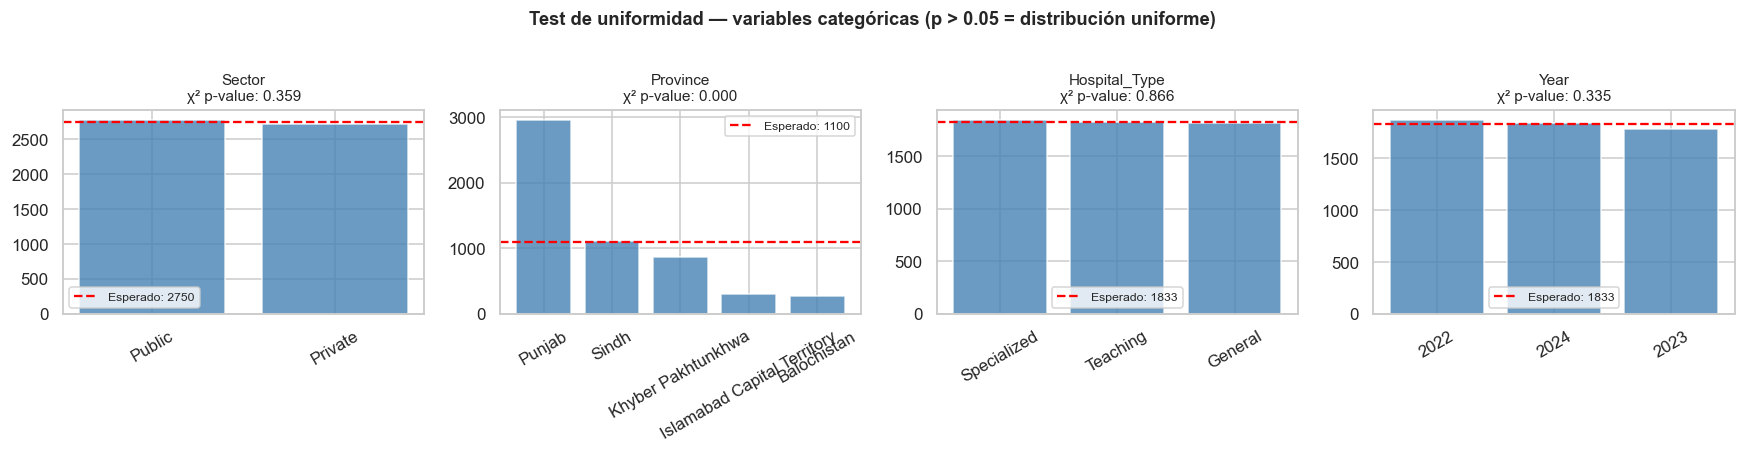


Balance exacto de categorías:
  Sector: {'Public': 50.6, 'Private': 49.4} %
  Province: {'Punjab': 53.8, 'Sindh': 20.3, 'Khyber Pakhtunkhwa': 15.7, 'Islamabad Capital Territory': 5.3, 'Balochistan': 4.9} %
  Hospital_Type: {'Specialized': 33.7, 'Teaching': 33.3, 'General': 33.1} %
  Year: {2022: 34.1, 2024: 33.4, 2023: 32.5} %


In [3]:
# --- Test de uniformidad: variables categóricas ---
cat_cols = ['Sector', 'Province', 'Hospital_Type', 'Year']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    # Chi2 test contra distribución uniforme
    chi2, p = stats.chisquare(counts.values)
    expected = len(df) / len(counts)
    
    ax.bar(counts.index.astype(str), counts.values, color='steelblue', alpha=0.8)
    ax.axhline(expected, color='red', linestyle='--', linewidth=1.5, label=f'Esperado: {expected:.0f}')
    ax.set_title(f'{col}\nχ² p-value: {p:.3f}', fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

plt.suptitle('Test de uniformidad — variables categóricas (p > 0.05 = distribución uniforme)', 
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nBalance exacto de categorías:')
for col in cat_cols:
    vc = df[col].value_counts()
    pct = (vc / len(df) * 100).round(1)
    print(f'  {col}: {dict(zip(vc.index, pct))} %')

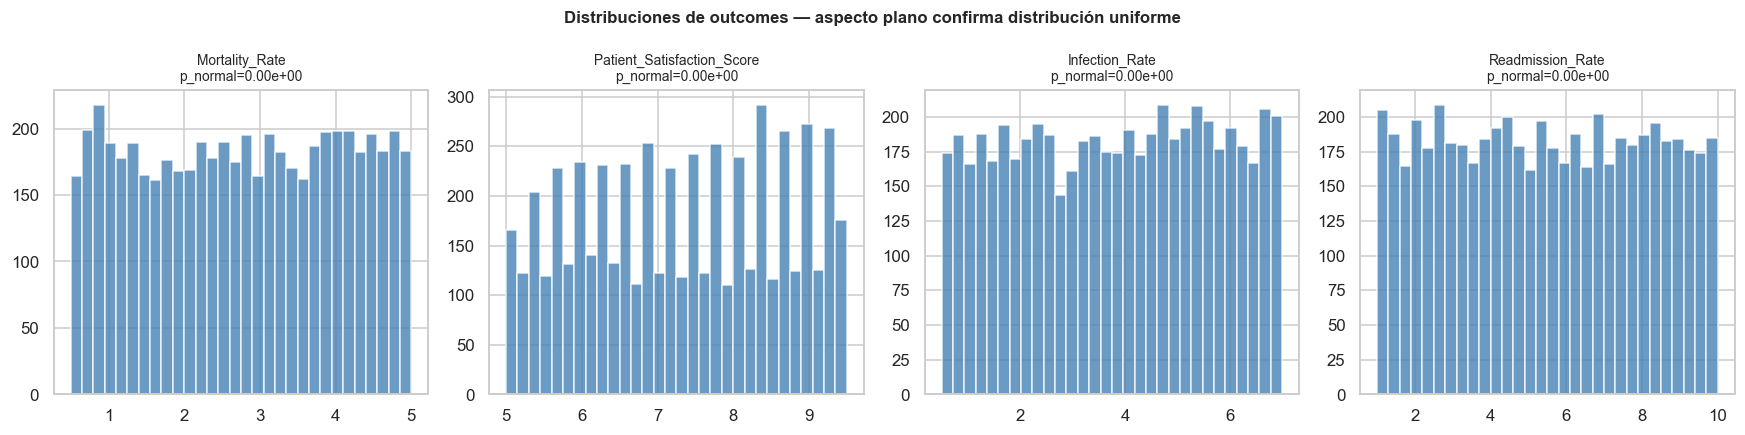

In [4]:
# --- Distribuciones de variables numéricas clave: ¿uniformes? ---
vars_to_check = ['Mortality_Rate', 'Patient_Satisfaction_Score', 'Infection_Rate', 'Readmission_Rate']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, vars_to_check):
    ax.hist(df[col], bins=30, color='steelblue', alpha=0.8, edgecolor='white')
    # Test de normalidad
    _, p_norm = stats.normaltest(df[col])
    ax.set_title(f'{col}\np_normal={p_norm:.2e}', fontsize=9)
    ax.set_xlabel('')

plt.suptitle('Distribuciones de outcomes — aspecto plano confirma distribución uniforme', 
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. La única brecha real: Público vs Privado

**Hipótesis H1:** Los privados tienen mejor calidad pero mayor costo.  
**Resultado EDA v1:** Solo se confirma la parte del costo. Acá lo vemos todo junto.

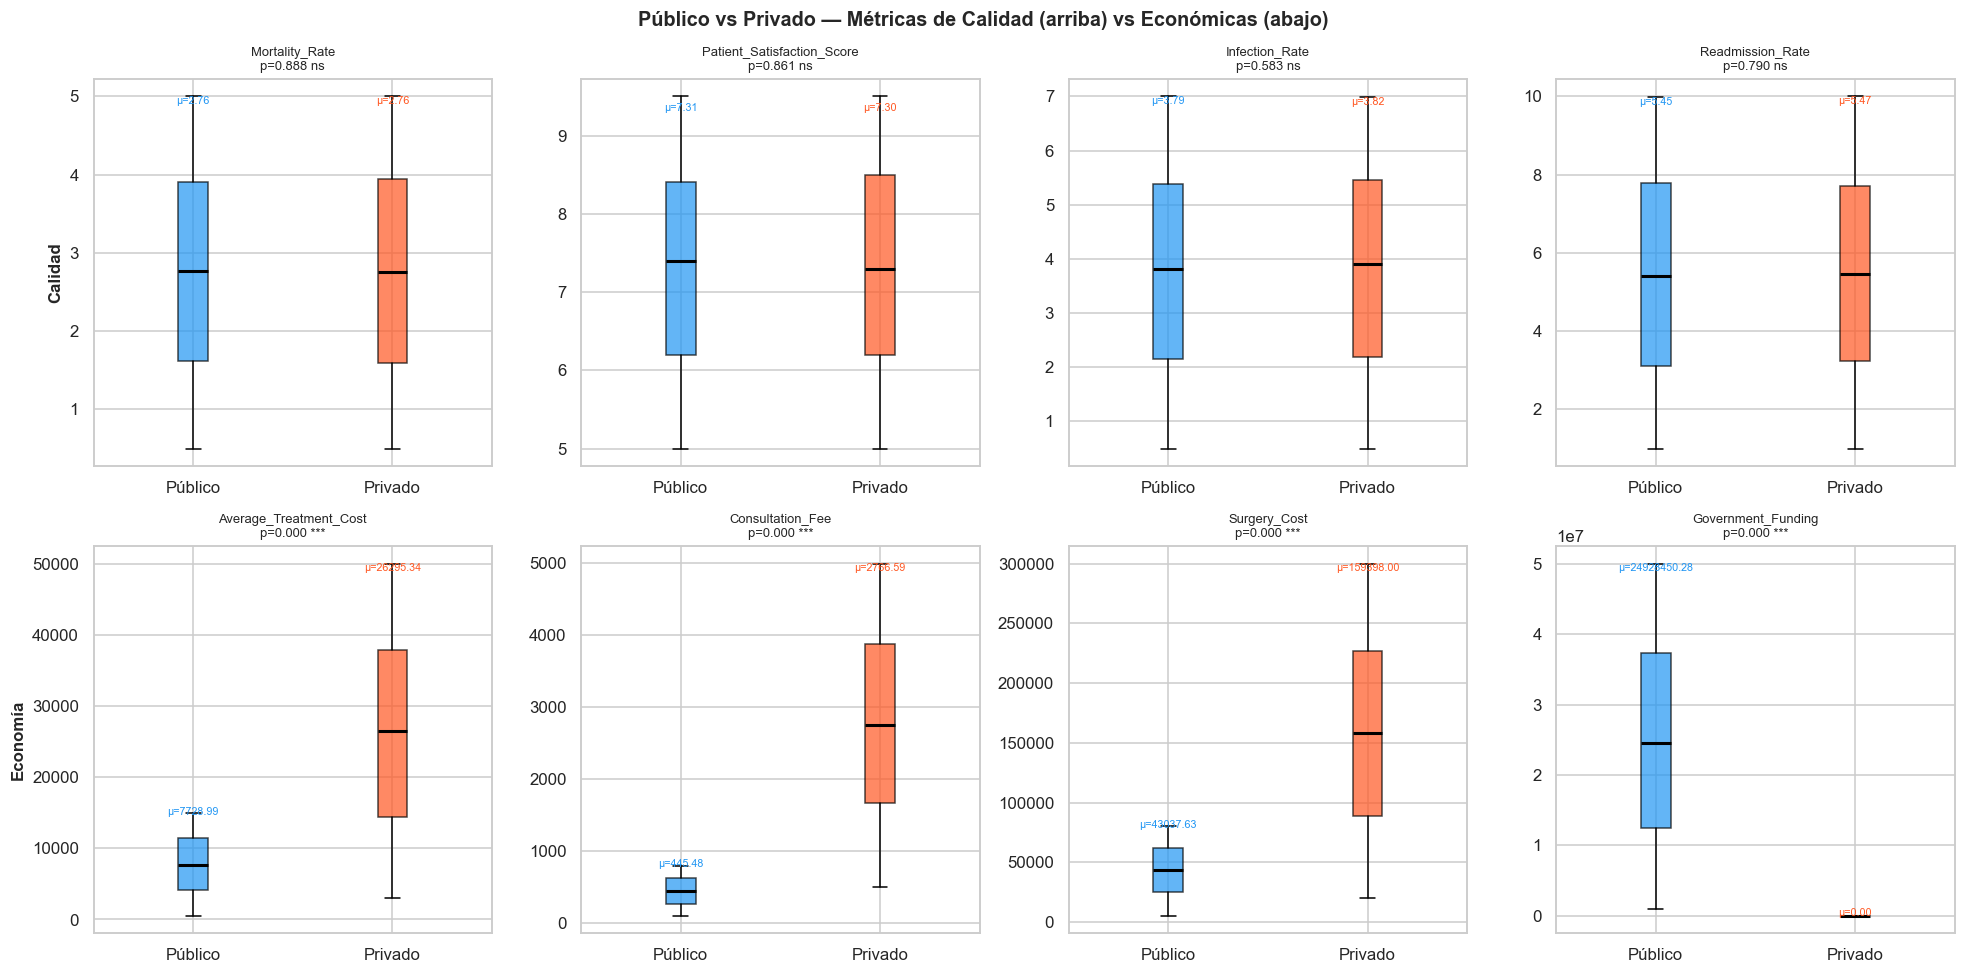


=== RESUMEN PÚBLICO vs PRIVADO ===

[Calidad]
  Mortality_Rate                      Público:      2.76 | Privado:      2.76 | Ratio: 1.00x
  Patient_Satisfaction_Score          Público:      7.31 | Privado:      7.30 | Ratio: 1.00x
  Infection_Rate                      Público:      3.79 | Privado:      3.82 | Ratio: 1.01x
  Readmission_Rate                    Público:      5.45 | Privado:      5.47 | Ratio: 1.00x

[Economía]
  Average_Treatment_Cost              Público:   7728.99 | Privado:  26295.34 | Ratio: 3.40x
  Consultation_Fee                    Público:    445.48 | Privado:   2766.59 | Ratio: 6.21x
  Surgery_Cost                        Público:  43037.63 | Privado: 159398.00 | Ratio: 3.70x
  Government_Funding                  Público: 24928450.28 | Privado:      0.00 | Ratio: 0.00x


In [5]:
# --- Dashboard Público vs Privado ---
metrics = {
    'Calidad': ['Mortality_Rate', 'Patient_Satisfaction_Score', 'Infection_Rate', 'Readmission_Rate'],
    'Economía': ['Average_Treatment_Cost', 'Consultation_Fee', 'Surgery_Cost', 'Government_Funding']
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

colors = {'Public': '#2196F3', 'Private': '#FF5722'}

for row_idx, (categoria, cols) in enumerate(metrics.items()):
    for col_idx, metric in enumerate(cols):
        ax = axes[row_idx, col_idx]
        
        pub = df[df['Sector'] == 'Public'][metric]
        priv = df[df['Sector'] == 'Private'][metric]
        
        # Mann-Whitney test
        _, p_val = stats.mannwhitneyu(pub, priv, alternative='two-sided')
        
        bp = ax.boxplot([pub, priv], labels=['Público', 'Privado'], patch_artist=True,
                        medianprops={'color': 'black', 'linewidth': 2})
        bp['boxes'][0].set_facecolor('#2196F3')
        bp['boxes'][0].set_alpha(0.7)
        bp['boxes'][1].set_facecolor('#FF5722')
        bp['boxes'][1].set_alpha(0.7)
        
        sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))
        ax.set_title(f'{metric}\np={p_val:.3f} {sig}', fontsize=8.5)
        
        # Medias
        ax.text(1, pub.max() * 0.98, f'μ={pub.mean():.2f}', ha='center', fontsize=7, color='#2196F3')
        ax.text(2, priv.max() * 0.98, f'μ={priv.mean():.2f}', ha='center', fontsize=7, color='#FF5722')
    
    axes[row_idx, 0].set_ylabel(categoria, fontsize=11, fontweight='bold')

plt.suptitle('Público vs Privado — Métricas de Calidad (arriba) vs Económicas (abajo)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla resumen
print('\n=== RESUMEN PÚBLICO vs PRIVADO ===')
for categoria, cols in metrics.items():
    print(f'\n[{categoria}]')
    for col in cols:
        pub_mean = df[df['Sector'] == 'Public'][col].mean()
        priv_mean = df[df['Sector'] == 'Private'][col].mean()
        ratio = priv_mean / pub_mean if pub_mean != 0 else float('inf')
        print(f'  {col:35s} Público: {pub_mean:9.2f} | Privado: {priv_mean:9.2f} | Ratio: {ratio:.2f}x')

## 3. ¿Los recursos determinan los outcomes? (H2)

**Hipótesis H2:** Más recursos → mejor calidad. El EDA v1 ya lo refutó (r < 0.05).  
Acá lo visualizamos directamente.

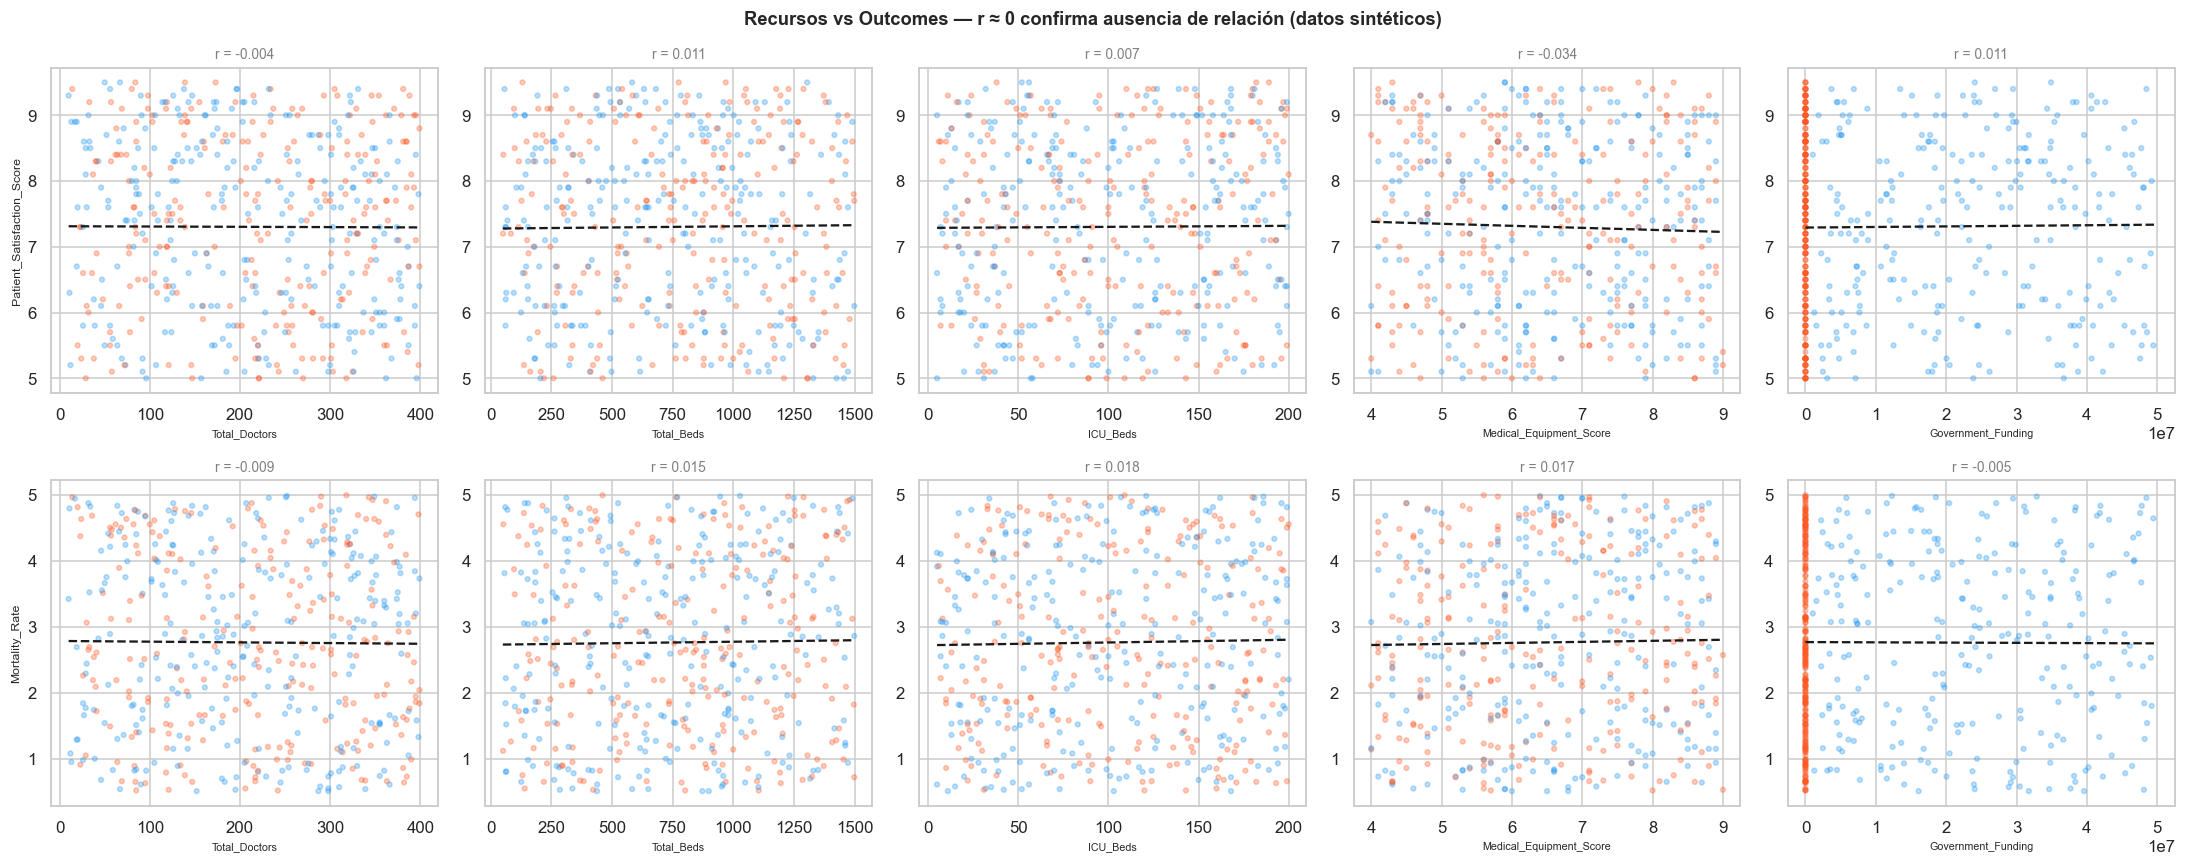


=== CORRELACIONES RECURSOS → OUTCOMES ===
Variable                       vs Satisfacción      vs Mortalidad       
Total_Doctors                  -0.0039               -0.0092
Total_Beds                     +0.0112               +0.0146
ICU_Beds                       +0.0068               +0.0180
Medical_Equipment_Score        -0.0342               +0.0174
Government_Funding             +0.0109               -0.0048


In [6]:
# --- Recursos vs Outcomes: scatter matrix ---
recursos = ['Total_Doctors', 'Total_Beds', 'ICU_Beds', 'Medical_Equipment_Score', 'Government_Funding']
outcomes = ['Patient_Satisfaction_Score', 'Mortality_Rate']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for row, outcome in enumerate(outcomes):
    for col, recurso in enumerate(recursos):
        ax = axes[row, col]
        
        # Sample para velocidad
        sample = df.sample(500, random_state=42)
        
        r, p = stats.pearsonr(df[recurso], df[outcome])
        
        color_map = sample['Sector'].map({'Public': '#2196F3', 'Private': '#FF5722'})
        ax.scatter(sample[recurso], sample[outcome], alpha=0.3, s=10, c=color_map)
        
        # Línea de tendencia
        z = np.polyfit(df[recurso], df[outcome], 1)
        p_fit = np.poly1d(z)
        x_line = np.linspace(df[recurso].min(), df[recurso].max(), 100)
        ax.plot(x_line, p_fit(x_line), 'k--', linewidth=1.5)
        
        ax.set_title(f'r = {r:.3f}', fontsize=9,
                     color='red' if abs(r) > 0.3 else 'gray')
        ax.set_xlabel(recurso, fontsize=7)
        if col == 0:
            ax.set_ylabel(outcome, fontsize=8)

plt.suptitle('Recursos vs Outcomes — r ≈ 0 confirma ausencia de relación (datos sintéticos)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla de correlaciones
print('\n=== CORRELACIONES RECURSOS → OUTCOMES ===')
print(f'{"Variable":30s} {"vs Satisfacción":20s} {"vs Mortalidad":20s}')
for r in recursos:
    r_sat, _ = stats.pearsonr(df[r], df['Patient_Satisfaction_Score'])
    r_mort, _ = stats.pearsonr(df[r], df['Mortality_Rate'])
    print(f'{r:30s} {r_sat:+.4f}               {r_mort:+.4f}')

## 4. Correlaciones del dataset — ¿qué sí se relaciona?


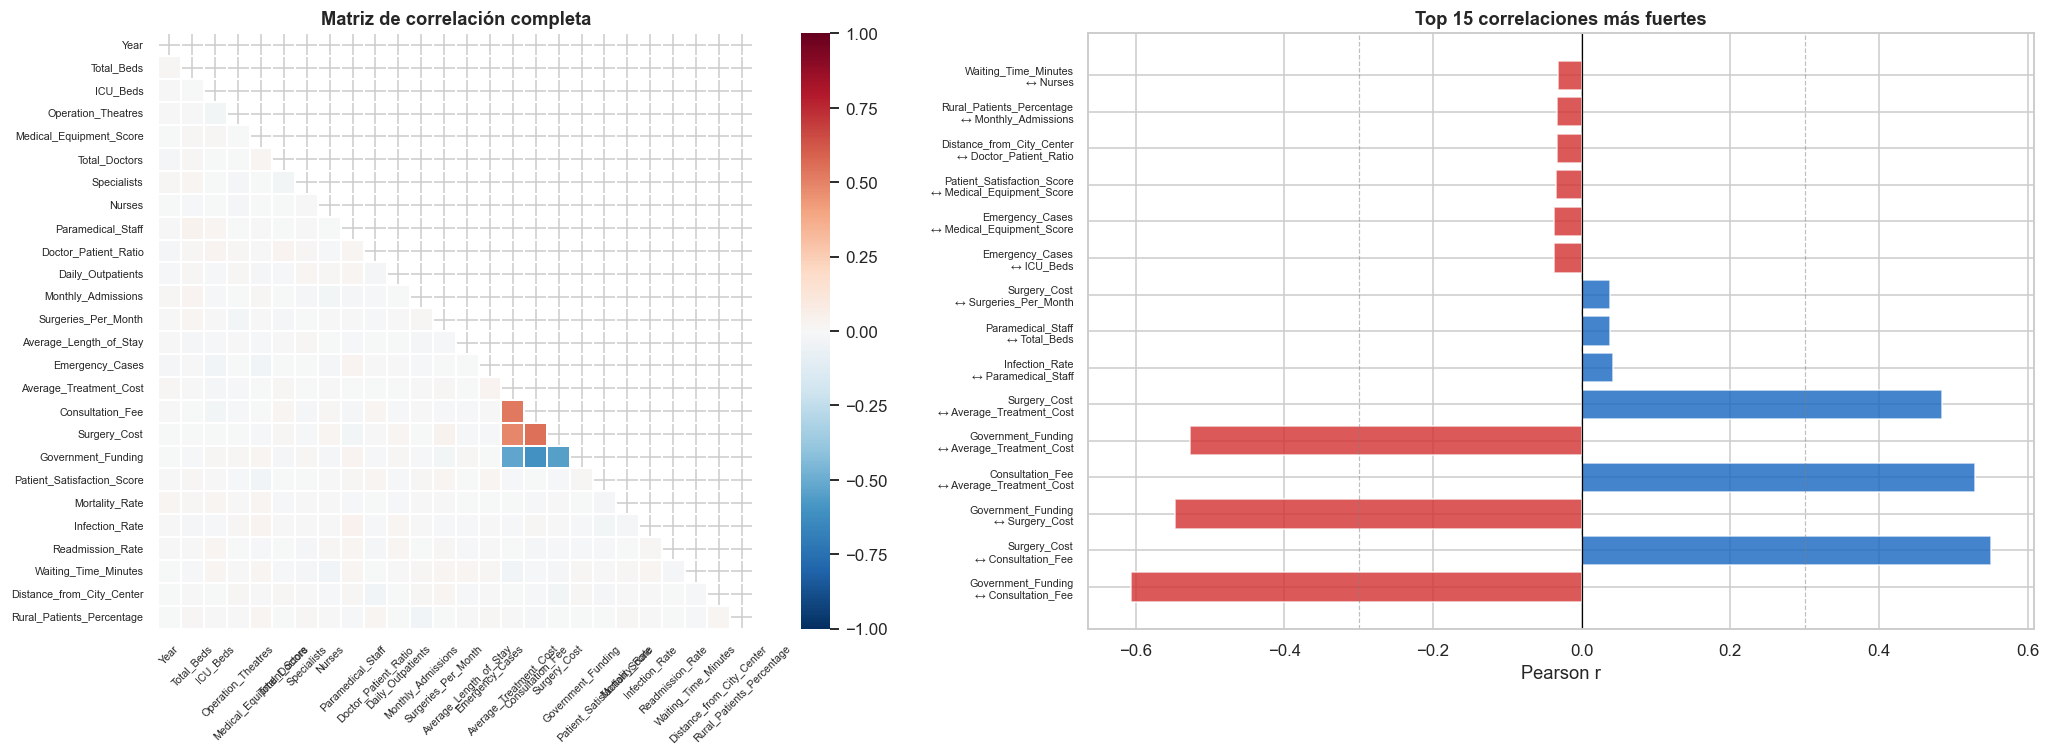


=== TOP CORRELACIONES ===
  Government_Funding             ↔ Consultation_Fee               r = -0.6061
  Surgery_Cost                   ↔ Consultation_Fee               r = +0.5506
  Government_Funding             ↔ Surgery_Cost                   r = -0.5470
  Consultation_Fee               ↔ Average_Treatment_Cost         r = +0.5299
  Government_Funding             ↔ Average_Treatment_Cost         r = -0.5267
  Surgery_Cost                   ↔ Average_Treatment_Cost         r = +0.4851
  Infection_Rate                 ↔ Paramedical_Staff              r = +0.0420
  Paramedical_Staff              ↔ Total_Beds                     r = +0.0381
  Surgery_Cost                   ↔ Surgeries_Per_Month            r = +0.0381
  Emergency_Cases                ↔ ICU_Beds                       r = -0.0373
  Emergency_Cases                ↔ Medical_Equipment_Score        r = -0.0370
  Patient_Satisfaction_Score     ↔ Medical_Equipment_Score        r = -0.0342
  Distance_from_City_Center      ↔ Do

In [7]:
# --- Heatmap completo ---
num_df = df.select_dtypes(include='number').drop(columns=['Hospital_ID'], errors='ignore')
corr = num_df.corr()

# Máscara triángulo superior
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Heatmap
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=False, ax=axes[0],
            linewidths=0.3, square=True)
axes[0].set_title('Matriz de correlación completa', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
axes[0].tick_params(axis='y', labelsize=7)

# Top correlaciones
corr_pairs = (corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
              .stack()
              .reset_index())
corr_pairs.columns = ['Var1', 'Var2', 'r']
corr_pairs['abs_r'] = corr_pairs['r'].abs()
top15 = corr_pairs.sort_values('abs_r', ascending=False).head(15)

colors_bar = ['#d32f2f' if r < 0 else '#1565c0' for r in top15['r']]
axes[1].barh([f"{row.Var1}\n↔ {row.Var2}" for _, row in top15.iterrows()],
             top15['r'], color=colors_bar, alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].axvline(0.3, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
axes[1].axvline(-0.3, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
axes[1].set_title('Top 15 correlaciones más fuertes', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Pearson r')
axes[1].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.show()

print('\n=== TOP CORRELACIONES ===')
for _, row in top15.iterrows():
    print(f'  {row.Var1:30s} ↔ {row.Var2:30s} r = {row.r:+.4f}')

## 5. Análisis geográfico y temporal (resumen compacto)

El EDA v1 mostró variabilidad mínima. Acá lo confirmamos en una sola vista.

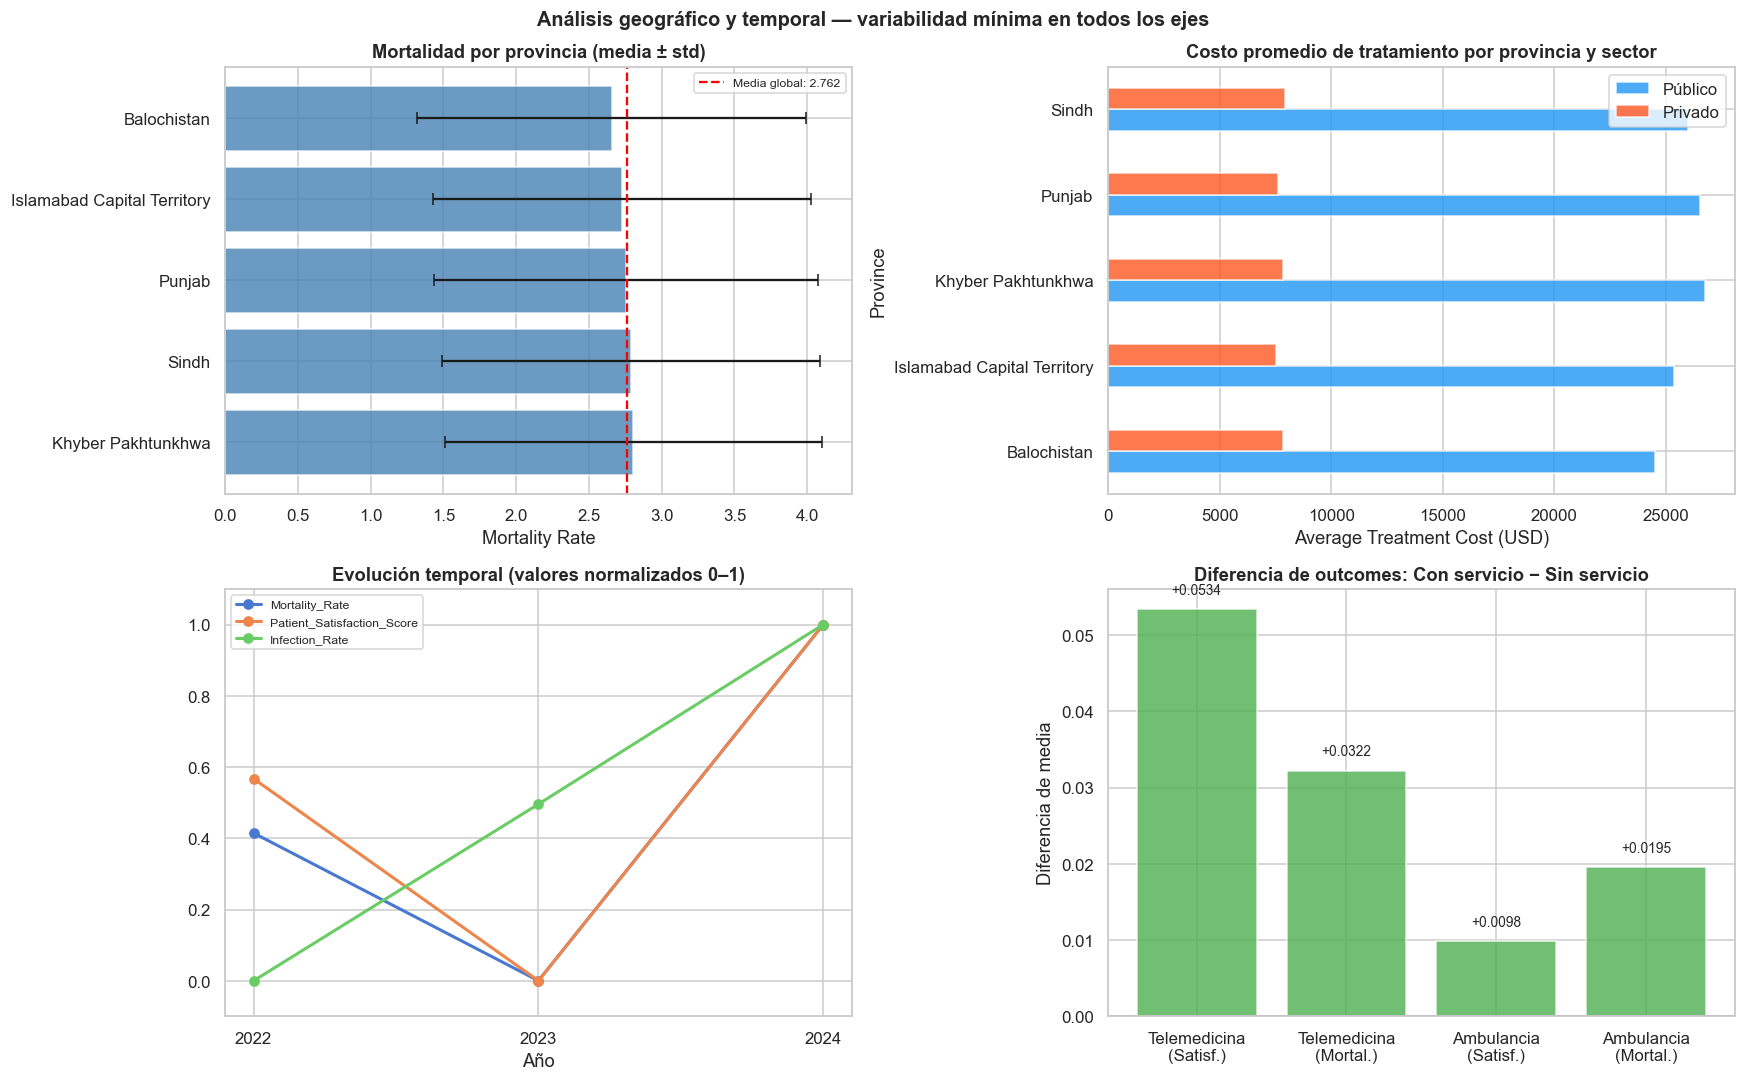

In [8]:
# --- Panel: 4 gráficos geográfico + temporal ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Mortalidad por provincia
prov_mort = df.groupby('Province')['Mortality_Rate'].agg(['mean', 'std']).reset_index()
prov_mort = prov_mort.sort_values('mean', ascending=False)
axes[0,0].barh(prov_mort['Province'], prov_mort['mean'], xerr=prov_mort['std'],
               color='steelblue', alpha=0.8, capsize=4)
axes[0,0].axvline(df['Mortality_Rate'].mean(), color='red', linestyle='--', linewidth=1.5,
                  label=f'Media global: {df["Mortality_Rate"].mean():.3f}')
axes[0,0].set_title('Mortalidad por provincia (media ± std)', fontweight='bold')
axes[0,0].set_xlabel('Mortality Rate')
axes[0,0].legend(fontsize=8)

# 2. Costo promedio por provincia y sector
prov_cost = df.groupby(['Province', 'Sector'])['Average_Treatment_Cost'].mean().unstack()
prov_cost.plot(kind='barh', ax=axes[0,1], color=['#2196F3', '#FF5722'], alpha=0.8)
axes[0,1].set_title('Costo promedio de tratamiento por provincia y sector', fontweight='bold')
axes[0,1].set_xlabel('Average Treatment Cost (USD)')
axes[0,1].legend(['Público', 'Privado'])

# 3. Evolución temporal — 3 métricas
temporal = df.groupby('Year')[['Mortality_Rate', 'Patient_Satisfaction_Score', 'Infection_Rate']].mean()
temporal_norm = (temporal - temporal.min()) / (temporal.max() - temporal.min())  # normalizar
for col in temporal_norm.columns:
    axes[1,0].plot(temporal_norm.index, temporal_norm[col], marker='o', linewidth=2, label=col)
axes[1,0].set_title('Evolución temporal (valores normalizados 0–1)', fontweight='bold')
axes[1,0].set_xlabel('Año')
axes[1,0].set_xticks([2022, 2023, 2024])
axes[1,0].legend(fontsize=8)
axes[1,0].set_ylim(-0.1, 1.1)

# 4. Telemedicina y ambulancia: ¿impacto real?
services = {
    'Telemedicina\n(Satisf.)': ('Telemedicine_Service', 'Patient_Satisfaction_Score'),
    'Telemedicina\n(Mortal.)': ('Telemedicine_Service', 'Mortality_Rate'),
    'Ambulancia\n(Satisf.)': ('Ambulance_Available', 'Patient_Satisfaction_Score'),
    'Ambulancia\n(Mortal.)': ('Ambulance_Available', 'Mortality_Rate'),
}

x_pos = range(len(services))
diffs = []
labels = []
for label, (service_col, metric_col) in services.items():
    yes = df[df[service_col] == 'Yes'][metric_col].mean()
    no = df[df[service_col] == 'No'][metric_col].mean()
    diffs.append(yes - no)
    labels.append(label)

bar_colors = ['#4CAF50' if d > 0 else '#F44336' for d in diffs]
axes[1,1].bar(labels, diffs, color=bar_colors, alpha=0.8)
axes[1,1].axhline(0, color='black', linewidth=1)
axes[1,1].set_title('Diferencia de outcomes: Con servicio − Sin servicio', fontweight='bold')
axes[1,1].set_ylabel('Diferencia de media')
for i, d in enumerate(diffs):
    axes[1,1].text(i, d + (0.002 if d >= 0 else -0.005), f'{d:+.4f}', ha='center', fontsize=9)

plt.suptitle('Análisis geográfico y temporal — variabilidad mínima en todos los ejes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Feature Engineering — preparación para Fases 1 y 2

Creamos variables derivadas que serán útiles para el clustering y los modelos.

In [ ]:
df_eng = df.copy()

# --- Variables derivadas ---
# 1. Ratio personal
df_eng['Nurse_to_Doctor_Ratio'] = df_eng['Nurses'] / df_eng['Total_Doctors'].replace(0, np.nan)
df_eng['ICU_per_Bed'] = df_eng['ICU_Beds'] / df_eng['Total_Beds'].replace(0, np.nan)
df_eng['Staff_Total'] = df_eng['Total_Doctors'] + df_eng['Nurses'] + df_eng['Paramedical_Staff']

# 2. Eficiencia económica
df_eng['Cost_per_Admission'] = df_eng['Average_Treatment_Cost'] / df_eng['Monthly_Admissions'].replace(0, np.nan)

# 3. Índice de eficiencia: satisfacción / costo normalizado
cost_norm = (df_eng['Average_Treatment_Cost'] - df_eng['Average_Treatment_Cost'].min()) / \
            (df_eng['Average_Treatment_Cost'].max() - df_eng['Average_Treatment_Cost'].min())
df_eng['Efficiency_Index'] = df_eng['Patient_Satisfaction_Score'] / (cost_norm + 0.01)

# 4. Resource Score (compuesto)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
resource_vars = ['Total_Beds', 'ICU_Beds', 'Total_Doctors', 'Specialists', 'Medical_Equipment_Score']
df_eng['Resource_Score'] = scaler.fit_transform(df_eng[resource_vars]).mean(axis=1)

# 5. Is_Rural: hospitales rurales (percentil 75+ de Rural_Patients_Percentage)
umbral_rural = df_eng['Rural_Patients_Percentage'].quantile(0.75)
df_eng['Is_Rural'] = (df_eng['Rural_Patients_Percentage'] >= umbral_rural).astype(int)

# --- Resumen de variables nuevas ---
new_vars = ['Nurse_to_Doctor_Ratio', 'ICU_per_Bed', 'Cost_per_Admission',
            'Efficiency_Index', 'Resource_Score']
print('=== VARIABLES DERIVADAS ===')
print(df_eng[new_vars].describe().T[['mean', 'std', 'min', 'max']].round(3).to_string())

# --- Efficiency Index: ¿los públicos son más eficientes? ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_eng.boxplot(column='Efficiency_Index', by='Sector', ax=axes[0])
axes[0].set_title('Efficiency Index por Sector')
axes[0].set_xlabel('')
plt.sca(axes[0])
plt.title('Efficiency Index (Satisfacción / Costo norm.)')

df_eng.boxplot(column='Resource_Score', by='Sector', ax=axes[1])
axes[1].set_title('Resource Score por Sector')
axes[1].set_xlabel('')
plt.sca(axes[1])
plt.title('Resource Score (compuesto)')

plt.suptitle('')
plt.tight_layout()
plt.show()

print('\nEfficiency Index por Sector:')
print(df_eng.groupby('Sector')['Efficiency_Index'].describe().round(3))

## 7. Conclusiones del EDA v2

### Hallazgos clave confirmados

| Hipótesis | Resultado | Evidencia |
|-----------|-----------|----------|
| H1: Privado = mejor calidad | ❌ RECHAZADA | Mann-Whitney ns en Mortality, Satisfaction, Infection |
| H1: Privado = mayor costo | ✅ CONFIRMADA | Ratio 3.4x en Average_Treatment_Cost |
| H2: Recursos → mejor outcomes | ❌ RECHAZADA | r < 0.05 en todos los pares |
| H3: Desigualdad geográfica | ❌ RECHAZADA | Variación mínima entre provincias |
| H6: Mejora temporal 22–24 | ❌ RECHAZADA | Sin tendencia detectable |
| H7: Telemedicina = mejor outcomes | ❌ RECHAZADA | Δ < 0.05 puntos |

### Naturaleza del dataset
- Variables categóricas con distribución **casi perfectamente uniforme** (chi2 p > 0.5)
- Outcomes con distribución plana (no normal), consistente con **generación aleatoria**
- Única correlación real: **Consultation_Fee ↔ Government_Funding (r ≈ -0.61)** → lógica económica público/privado

### Para las fases siguientes
- **Fase 1:** Los tests estadísticos confirmarán la ausencia de diferencias (foco en el eje económico)
- **Fase 2:** Clustering probablemente generará segmentos basados en variables económicas. El R² en regresión será bajo (< 0.3)
- **Fase 3 (DEA):** El análisis de eficiencia relativa es el análisis más prometedor dado que la variación económica sí existe
- Las variables derivadas (`Resource_Score`, `Efficiency_Index`, `Cost_per_Admission`) serán los inputs principales del clustering

In [ ]:
# Guardar dataset con features nuevas para usar en fases siguientes
df_eng.to_csv('2_pakistan_healthcare_engineered.csv', index=False)
print(f'Dataset con features guardado: {df_eng.shape[0]} filas × {df_eng.shape[1]} columnas')
print(f'Columnas nuevas: {[c for c in df_eng.columns if c not in df.columns]}')